Accuracy Score=100.00%
Accuracy Report:
               precision    recall  f1-score   support

Not Survived       1.00      1.00      1.00        53
    Survived       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



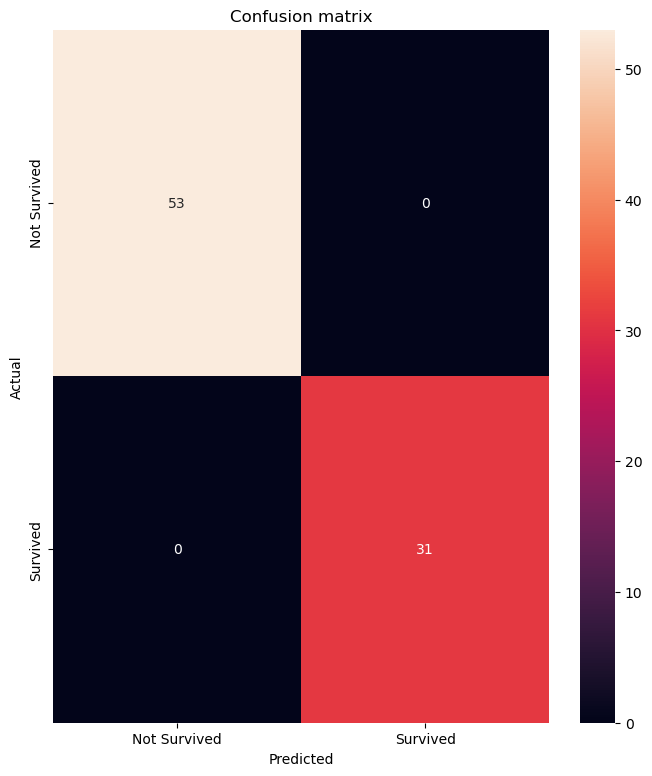

Pipeline(steps=[('Preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Num_data', SimpleImputer(),
                                                  Index(['Pclass', 'Age'], dtype='object')),
                                                 ('Cat_Data',
                                                  Pipeline(steps=[('Imputer_cat',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Encodin',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Sex', 'Embarked'], dtype='object'))])),
                ('Standard Scaler', StandardScaler()),
                ('Tree', DecisionTreeClassifier(random_state=42))])

In [68]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn import tree
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

#creating the object for each model
Sim_num=SimpleImputer(strategy='mean')
Sim_cat=SimpleImputer(strategy='most_frequent')
ohe=OneHotEncoder(handle_unknown='ignore',sparse_output=False)
scaled=StandardScaler()
dt=tree.DecisionTreeClassifier(random_state=42)

df=pd.read_csv(r'C:\Users\KIIT0001\Desktop\Python\CSV\Titanic.csv')
#print(df)
df.drop(['PassengerId','Name','SibSp','Ticket','Cabin','Parch','Fare'],axis='columns',inplace=True)
X=df.drop('Survived',axis='columns')
Y=df.Survived.apply(lambda x:"Survived" if x==1 else "Not Survived")

#for storing numeric val columns
num_cols=X.select_dtypes(include=['int64','float64','float32']).columns

#for storing categorical val columns
cat_cols=X.select_dtypes(include=['category','object']).columns

#creating a pipeline for pre-processing of data
preprocessor=ColumnTransformer([
    ('Num_data',Sim_num,num_cols),
    ('Cat_Data',Pipeline([
        ('Imputer_cat',Sim_cat),
        ('Encodin',ohe)
    ]),cat_cols)
],remainder='passthrough')

#Creating the final model pipeline
model=Pipeline([
    ('Preprocessing',preprocessor),
    ('Standard Scaler',scaled),
    ('Tree',dt)
])

X_train, X_test, y_train, y_test=train_test_split(X,Y,test_size=0.2,shuffle=True,stratify=Y,random_state=42)
model.fit(X_train,y_train)
pred=model.predict(X_test)
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import accuracy_score
print(f"Accuracy Score={accuracy_score(y_test,pred)*100:.2f}%")
print("Accuracy Report:\n",classification_report(y_test,pred))

#Saving the model
import pickle
pickle.dump(model,open(r'C:\Users\KIIT0001\Desktop\Python\Models\Titanic_Precition.pkl','wb'))

#utilizing the saved model
md = pickle.load(open(r'C:\Users\KIIT0001\Desktop\Python\Models\Titanic_Precition.pkl','rb'))

#visualizing the acc
import seaborn as sns
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test,pred)
plt.figure(figsize=(8,9))
sns.heatmap(cm,annot=True,xticklabels=['Not Survived','Survived'],yticklabels=['Not Survived','Survived'])
plt.title("Confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#visualizing the pipelin
from sklearn import set_config
st=set_config(display='diagram')
model